In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
path      = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\CreditData\PrepCDS.parquet"
df_longer = (pd
    .read_parquet(path = path, engine = "pyarrow")
    .melt(id_vars = ["date", "SecurityGroup"])
    .dropna())

Text(0.5, 0.98, 'Comparing Historical Data')

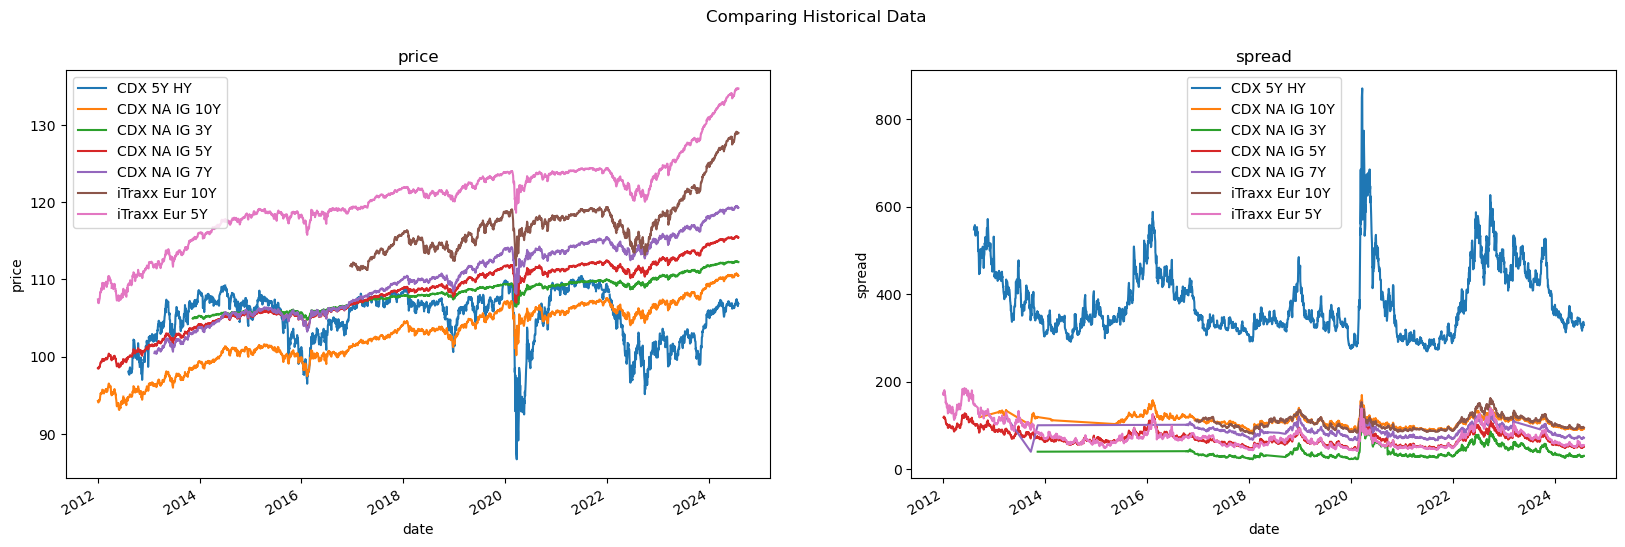

In [3]:
variables = df_longer.variable.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(variables), figsize = (20,6))

for variable, ax in zip(variables, axes.flatten()): 

    (df_longer
        .loc[lambda x: x.variable == variable]
        .rename(columns = {"SecurityGroup": ""})
        .pivot(index = "date", columns = "", values = "value")
        .plot(
            ax     = ax,
            title  = variable,
            ylabel = variable))

fig.suptitle("Comparing Historical Data")